In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import polars as pl
import pickle
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt
import cv2

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.manifold import Isomap
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm import tqdm


# --- Configuración de rutas ---

In [4]:
# Ruta al archivo Pickle generado
PKL_FILE_PATH = "/content/drive/MyDrive/DMA/datos_procesados/rostros_dataset.pkl"

TRAIN_OUTPUT_PATH = "/content/drive/MyDrive/DMA/datos_procesados/rostros_isomap_train.pkl"
TEST_OUTPUT_PATH = "/content/drive/MyDrive/DMA/datos_procesados/rostros_isomap_test.pkl"

# Rutas para guardar los modelos
PCA_MODEL_PATH = "/content/drive/MyDrive/DMA/modelos_procesamiento/pca_model.pkl"
ISOMAP_MODEL_PATH = "/content/drive/MyDrive/DMA/modelos_procesamiento/isomap_model.pkl"
SCALER_MODEL_PATH = "/content/drive/MyDrive/DMA/modelos_procesamiento/scaler_model.pkl"


# Fija un estado aleatorio para resultados reproducibles
RANDOM_STATE = 42

# --- Funciones ---

In [8]:
def load_data(file_path):
    """
    Carga el DataFrame de Polars desde un archivo Pickle y extrae los datos.
    """
    if not os.path.exists(file_path):
        print(f"Error: El archivo {file_path} no fue encontrado.")
        return None, None, None

    with open(file_path, 'rb') as f:
        df = pickle.load(f)

    # Extrae las imágenes (caras aplanadas) y las etiquetas
    # Asegurarse de que 'imagen_data' es una lista o array de NumPy antes de stack
    if isinstance(df['imagen_data'].iloc[0], np.ndarray):
        X = np.stack(df['imagen_data'].to_numpy())
    else:
        # Handle cases where data might not be NumPy arrays (e.g., lists)
        X = np.array(list(df['imagen_data'].to_numpy()))

    y = df['etiqueta'].to_numpy()

    # Devuelve también los nombres de archivo por si son necesarios
    filenames = df['nombre_original'].to_numpy()

    print(f"Datos cargados. {X.shape[0]} imágenes encontradas con {X.shape[1]} píxeles cada una.")
    print(f"Número de etiquetas únicas: {len(np.unique(y))}")

    return X, y, filenames

def find_min_k_for_isomap_connectivity(X, max_k=50):
    """
    Encuentra el valor más pequeño de k (número de vecinos) para que el
    grafo de conectividad del ISOMAP sea una única componente conexa.
    También retorna la lista de número de componentes para cada k probado.

    Parámetros:
    - X (np.ndarray): Matriz de datos de entrada (imágenes aplanadas).
    - max_k (int): Valor máximo de k a probar.

    Devuelve:
    - tuple: (min_k, components_per_k).
             min_k (int): El valor mínimo de k. Si no se encuentra, devuelve -1.
             components_per_k (list): Lista con el número de componentes para cada k.
    """
    if X is None or X.shape[0] < 2:
        print("Datos insuficientes para construir un grafo.")
        return -1, []

    n_samples = X.shape[0]

    # Límite superior para k es n_samples - 1
    max_k = min(max_k, n_samples - 1)

    components_per_k = []

    for k in range(1, max_k + 1):
        print(f"Probando k = {k}...")

        # 1. Construye el grafo de k-vecinos más cercanos
        knn_graph = NearestNeighbors(n_neighbors=k, algorithm='brute').fit(X)
        connectivity_graph = knn_graph.kneighbors_graph(X, mode='connectivity')

        # 2. Cuenta las componentes conexas
        n_components, labels = connected_components(connectivity_graph)
        components_per_k.append(n_components)

        # 3. Comprueba si el grafo es conexo (una única componente)
        if n_components == 1:
            print("-" * 50)
            print(f"¡El grafo es conexo con k = {k}!")
            print("-" * 50)
            return k, components_per_k

    print(f"El grafo no se volvió conexo después de probar hasta k = {max_k}.")
    return -1, components_per_k

#--- Carga de Datos ---

In [9]:
images_data, labels_data, filenames_data = load_data(PKL_FILE_PATH)

Datos cargados. 387 imágenes encontradas con 4096 píxeles cada una.
Número de etiquetas únicas: 13


## Division de datos en conjuntos de entrenamiento y prueba

In [10]:
if images_data is not None:
    # Usamos stratify=labels para asegurar que la proporción de etiquetas sea similar en ambos conjuntos
    X_train, X_test, y_train, y_test = train_test_split(
        images_data, labels_data, test_size=0.2, random_state=RANDOM_STATE, stratify=labels_data
    )
    print(f"\nDatos divididos:")
    print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
    print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")
    print(f"Tamaño de las etiquetas de entrenamiento (y_train): {y_train.shape}")
    print(f"Tamaño de las etiquetas de prueba (y_test): {y_test.shape}")


Datos divididos:
Tamaño del conjunto de entrenamiento (X_train): (309, 4096)
Tamaño del conjunto de prueba (X_test): (78, 4096)
Tamaño de las etiquetas de entrenamiento (y_train): (309,)
Tamaño de las etiquetas de prueba (y_test): (78,)


#Aumentacion de datos (Solo en Conjunto de Training)

In [ ]:
# Parámetros del aumento de datos
TARGET_SIZE = (64, 64) # Tamaño original de tus imágenes
NUM_AUGMENTATIONS_PER_IMAGE = 2 # Cantidad de copias aumentadas por cada imagen original

# Listas para almacenar las imágenes aumentadas
X_train_augmented_list = []
y_train_augmented_list = []

# Recorrer cada imagen del conjunto de entrenamiento
print("\nIniciando Data Augmentation en el conjunto de entrenamiento...")
for i in tqdm(range(X_train.shape[0]), desc="Aumentando imágenes"):
    imagen_plana = X_train[i]
    etiqueta = y_train[i]

    # Redimensiona la imagen plana a su forma original (64x64) para las transformaciones
    imagen_original = imagen_plana.reshape(TARGET_SIZE).astype(np.uint8)

    # Añadir la imagen original a las listas
    X_train_augmented_list.append(imagen_plana)
    y_train_augmented_list.append(etiqueta)

    # Generar y aplicar las transformaciones
    for _ in range(NUM_AUGMENTATIONS_PER_IMAGE):

        # 1. Volteo horizontal (Flip)
        if np.random.rand() > 0.5:
            imagen_aumentada = cv2.flip(imagen_original, 1)
        else:
            imagen_aumentada = imagen_original.copy()

        # 2. Rotación leve (-10 a 10 grados)
        rot_angle = np.random.uniform(-10, 10)
        M = cv2.getRotationMatrix2D((TARGET_SIZE[0] / 2, TARGET_SIZE[1] / 2), rot_angle, 1)
        imagen_aumentada = cv2.warpAffine(imagen_aumentada, M, TARGET_SIZE, borderValue=0)

        # 3. Ajuste de brillo y contraste
        alpha = np.random.uniform(0.8, 1.2)  # Contraste
        beta = np.random.uniform(-10, 10)  # Brillo
        imagen_aumentada = cv2.convertScaleAbs(imagen_aumentada, alpha=alpha, beta=beta)

        # Aplanar la imagen aumentada y añadirla a la lista
        X_train_augmented_list.append(imagen_aumentada.flatten())
        y_train_augmented_list.append(etiqueta)

# Convertir las listas a arrays de NumPy
X_train = np.array(X_train_augmented_list)
y_train = np.array(y_train_augmented_list)

print(f"\nData Augmentation completa. Nuevo tamaño del conjunto de entrenamiento:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")


Iniciando Data Augmentation en el conjunto de entrenamiento...


Aumentando imágenes: 100%|██████████| 320/320 [00:00<00:00, 148585.99it/s]


Data Augmentation completa. Nuevo tamaño del conjunto de entrenamiento:
X_train: (320, 4096)
y_train: (320,)


# ISOMAP
ISOMAP es un método de reducción de dimensionalidad no lineal que sigue estos pasos:

Construcción del grafo: Se conecta cada punto con sus k vecinos más cercanos.
Cálculo de distancias geodésicas: Se miden las distancias más cortas a lo largo del grafo (no en línea recta).
Proyección con MDS (Multidimensional Scaling): Se proyectan los puntos al nuevo espacio de menor dimensión.
Si el grafo resultante no es conexo (es decir, tiene múltiples componentes desconectadas), ISOMAP no puede calcular correctamente las distancias entre todos los puntos, y esto puede llevar a fallos en la ejecución del algoritmo, resultados erróneos o sin sentido y/o matrices dispersas o con distancias infinitas.

Cuando no todos los nodos están conectados directa o indirectamente entre sí, el grafo no es conexo (compuesto por varias componentes conexas independientes).

## Análisis de Conectividad en ISOMAP - Determinacion de k-vecinos
Previamentes a la aplicacion de ISOMAP se realiza un análisis de conectividad para verificar que el grafo de vecinos más cercanos construido por ISOMAP esté completamente conectado (todos los puntos están directa o indirectamente conectados entre sí)

El objetivo del análisis de conectividad es encontrar el valor más pequeño de k (número de vecinos) tal que el grafo tenga una única componente conexa. De esta manera ISOMAP puede operar correctamente sobre el conjunto de datos.

Probando k = 1...
Probando k = 2...
Probando k = 3...
Probando k = 4...
Probando k = 5...
Probando k = 6...
Probando k = 7...
Probando k = 8...
Probando k = 9...
Probando k = 10...
Probando k = 11...
Probando k = 12...
Probando k = 13...
--------------------------------------------------
¡El grafo es conexo con k = 13!
--------------------------------------------------

El valor más pequeño de k para un grafo conexo es: 13


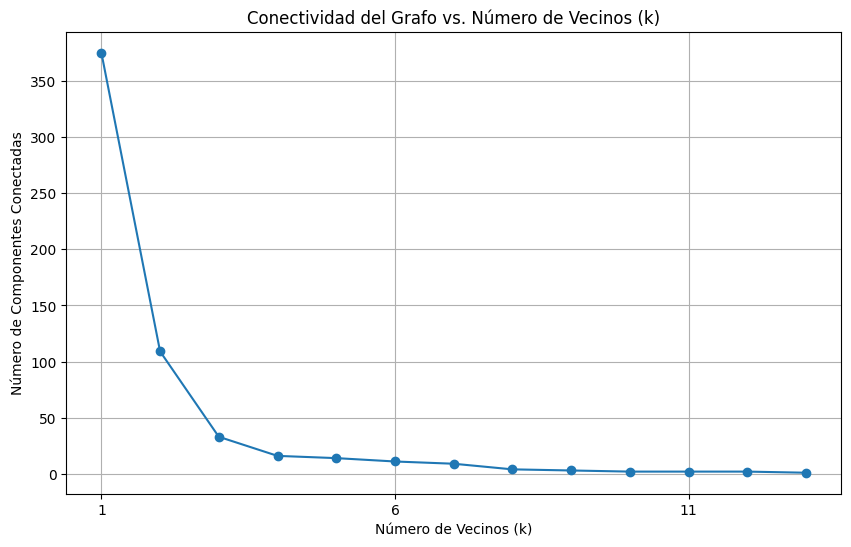

In [47]:
# 1. Inicializar el StandardScaler
scaler_connectivity = StandardScaler()

# 2. Escalar los datos para el análisis de conectividad
# Usamos images_data que son los datos completos cargados inicialmente
images_data_scaled_connectivity = scaler_connectivity.fit_transform(images_data)

# Encontrar el valor mínimo de k y obtener los componentes por k
min_k, components_per_k = find_min_k_for_isomap_connectivity(images_data_scaled_connectivity, max_k=50)

if min_k != -1:
    print(f"\nEl valor más pequeño de k para un grafo conexo es: {min_k}")
else:
    print("\nNo se encontró un valor de k adecuado.")

# Graficar el número de componentes vs k
k_values = range(1, len(components_per_k) + 1)
plt.figure(figsize=(10, 6))
plt.plot(k_values, components_per_k, marker='o')
plt.xlabel("Número de Vecinos (k)")
plt.ylabel("Número de Componentes Conectadas")
plt.title("Conectividad del Grafo vs. Número de Vecinos (k)")
plt.grid(True)
plt.xticks(np.arange(1, len(components_per_k) + 1, 5))
plt.show()

# **Búsqueda de hiperparámetros para ISOMAP y MLP utilizando validación cruzada.**

Este método evalúa los parámetros de ISOMAP basándose en la capacidad de un clasificador MLP para predecir las etiquetas en el espacio de baja dimensión.



1.   Crea un Pipeline: Combina el paso de reducción de dimensionalidad con ISOMAP y el paso de clasificación con MLP en un solo objeto. Esto es fundamental para evitar el "data leakage" (fuga de datos) durante la validación cruzada.
2.   Define un Grid Search: Prepara una cuadrícula de parámetros para buscar en ambos componentes del pipeline: Isomap (n_neighbors, n_components) y MLPClassifier (hidden_layer_sizes, activation).
1.   Realiza la Validación Cruzada: Utiliza GridSearchCV para entrenar y evaluar el pipeline con cada combinación de parámetros, asegurando que el rendimiento sea generalizable y no se sobreajuste a un solo subconjunto de datos.
2.   Evalúa el Mejor Modelo: Una vez encontrada la mejor combinación de parámetros en el conjunto de entrenamiento, se evalúa el rendimiento del modelo final en un conjunto de datos de prueba completamente nuevo para obtener una métrica de rendimiento imparcial

In [8]:
# 3. Definir el Pipeline
# El pipeline encadena StandardScaler, PCA (opcional), Isomap y MLPClassifier
# Se incluye un paso condicional para PCA

steps = [('scaler', StandardScaler())]

# Añadir PCA solo si N_COMPONENTS_PCA es distinto de 0
if N_COMPONENTS_PCA != 0:
    steps.append(('pca', PCA(n_components=N_COMPONENTS_PCA, random_state=RANDOM_STATE)))

steps.append(('isomap', Isomap()))
steps.append(('mlp', MLPClassifier(random_state=RANDOM_STATE)))

pipeline = Pipeline(steps)


# 4. Definir la cuadrícula de parámetros a buscar (Grid)
param_grid = {
    # Hiperparámetros de Isomap
    'isomap__n_neighbors': [6,7,8,9,10,11,12,13,14, 15, 20, 25],
    'isomap__n_components': [5,6,7,8,9,10,11,12,13,14, 15, 20, 25, 30, 40],

    # Hiperparámetros del MLP
    'mlp__hidden_layer_sizes': [(50,), (100,), (50, 25)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001],
    'mlp__max_iter': [200]
}

# Si PCA está en el pipeline, agregar sus parámetros al grid
if 'pca' in [name for name, _ in pipeline.steps]:
    param_grid['pca__n_components'] = [50, 100, 150] # Puedes ajustar estos valores


# 5. Configurar y ejecutar el Grid Search con validación cruzada
# Usa el número de folds que prefieras, 3 es un buen punto de partida
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

print("\nIniciando Grid Search...")
grid_search.fit(X_train, y_train)

# 6. Imprimir los resultados del Grid Search
print("\n" + "="*50)
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

print("\nMejor puntuación de validación cruzada (Precisión):")
print(f"{grid_search.best_score_:.4f}")
print("="*50)

# 7. Evaluar el mejor modelo en el conjunto de prueba
print("\nEvaluando el mejor modelo en el conjunto de prueba...")
best_pipeline = grid_search.best_estimator_
y_pred = best_pipeline.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred)
print(f"\nPrecisión final en el conjunto de prueba: {final_accuracy:.4f}")

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))


Iniciando Grid Search...
Fitting 3 folds for each of 2160 candidates, totalling 6480 fits


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])



Mejores parámetros encontrados:
{'isomap__n_components': 10, 'isomap__n_neighbors': 9, 'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (100,), 'mlp__max_iter': 200}

Mejor puntuación de validación cruzada (Precisión):
0.9313

Evaluando el mejor modelo en el conjunto de prueba...

Precisión final en el conjunto de prueba: 0.9250

Reporte de Clasificación:
              precision    recall  f1-score   support

   Alejandro       1.00      0.67      0.80         6
    Cristian       1.00      1.00      1.00         5
      Daniel       1.00      1.00      1.00         5
    Federico       0.86      0.86      0.86         7
     Gabriel       1.00      1.00      1.00         8
   Guadalupe       0.88      1.00      0.93         7
     Gustavo       1.00      1.00      1.00         5
   Jorgelina       0.77      0.91      0.83        11
       José       0.80      0.80      0.80         5
    Mauricio       1.00      0.75      0.86         4
     Natalia       

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# --- Seleccion de Parametros de Recuccion de Dimensionalidad ---

Se selecciona una Modelo de ISOMAP con:


* Numero de Vecinos = 13
* Cantidad de Componentes = 30


  Se propone un enfoque dual (PCA + Isomap) para manejar conjuntos de datos de alta dimensionalidad como los de imágenes.
  Opcional el uso de PCA para preparar datos para que el algoritmo no lineal de Isomap funcione correctamente.


In [11]:
N_COMPONENTS_PCA = 0

N_NEIGHBORS = 13
N_COMPONENTS_ISOMAP = 30

In [62]:
# 1. Inicializar el StandardScaler
scaler = StandardScaler()

# 2. Escalar los datos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Guarda los modelos escalados
os.makedirs(os.path.dirname(SCALER_MODEL_PATH), exist_ok=True)
with open(SCALER_MODEL_PATH, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Modelo StandardScaler guardado en {SCALER_MODEL_PATH}")

Modelo StandardScaler guardado en /content/drive/MyDrive/DMA/modelos_procesamiento/scaler_model.pkl


In [63]:
# Se ejecuta PCA en caso que N_COMPONENTS_PCA sea distinto de cero
# Se ejecuta ISOMAP en caso que N_NEIGHBOR y N_COMPONENTS_ISOMAP sean ambos distintos de cero

# 3. Reducir la dimensionalidad con PCA antes de aplicar Isomap (opcional)
if N_COMPONENTS_PCA != 0:
    pca = PCA(n_components=N_COMPONENTS_PCA, random_state=RANDOM_STATE)
    X_train_transformed = pca.fit_transform(X_train_scaled)
    X_test_transformed = pca.transform(X_test_scaled)

    # Guardar el modelo PCA
    os.makedirs(os.path.dirname(PCA_MODEL_PATH), exist_ok=True)
    with open(PCA_MODEL_PATH, 'wb') as f:
        pickle.dump(pca, f)
    print(f"Modelo PCA guardado en {PCA_MODEL_PATH}")

else:
    # Si PCA no se aplica, los datos transformados son los datos escalados
    X_train_transformed = X_train_scaled
    X_test_transformed = X_test_scaled
    print("PCA no se aplica porque N_COMPONENTS_PCA es cero.")

# 4. Inicializar y aplicar Isomap en los datos transformados (escalados o PCA+escalados)
if N_NEIGHBORS != 0 and N_COMPONENTS_ISOMAP != 0:
  isomap = Isomap(n_neighbors=N_NEIGHBORS, n_components=N_COMPONENTS_ISOMAP)

  try:
      X_train_isomap = isomap.fit_transform(X_train_transformed)
      X_test_isomap = isomap.transform(X_test_transformed)

      # Guardar el modelo Isomap
      with open(ISOMAP_MODEL_PATH, 'wb') as f:
          pickle.dump(isomap, f)
      print(f"Modelo Isomap guardado en {ISOMAP_MODEL_PATH}")

      print("Isomap aplicado correctamente.")

      print(f"Guardando los datos de entrenamiento transformados en {TRAIN_OUTPUT_PATH}...")
      with open(TRAIN_OUTPUT_PATH, 'wb') as f:
          pickle.dump({'data': X_train_isomap, 'labels': y_train}, f)

      print(f"Guardando los datos de prueba transformados en {TEST_OUTPUT_PATH}...")
      with open(TEST_OUTPUT_PATH, 'wb') as f:
          pickle.dump({'data': X_test_isomap, 'labels': y_test}, f)

      print("Archivos de datos guardados con éxito.")

  except Exception as e:
      print(f"ERROR: Fallo al aplicar Isomap. Causa: {e}")

else:
    print("Isomap no se aplica porque N_NEIGHBORS o N_COMPONENTS_ISOMAP son cero.")

PCA no se aplica porque N_COMPONENTS_PCA es cero.
Modelo Isomap guardado en /content/drive/MyDrive/DMA/modelos_procesamiento/isomap_model.pkl
Isomap aplicado correctamente.
Guardando los datos de entrenamiento transformados en /content/drive/MyDrive/DMA/datos_procesados/rostros_isomap_train.pkl...
Guardando los datos de prueba transformados en /content/drive/MyDrive/DMA/datos_procesados/rostros_isomap_test.pkl...
Archivos de datos guardados con éxito.


#####Visualizacion de las componentes princiales

In [36]:
if N_COMPONENTS_PCA != 0:
    # visualizar los EigenFaces
    print("\nVisualizando los EigenFaces (componentes principales de PCA)...")

    # Obtener la forma original de una imagen para redimensionar los componentes
    # Asumimos que la forma es 64x64, ajusta si es diferente
    image_shape = (64, 64)

    fig, axes = plt.subplots(3, 5, figsize=(15, 6),
                             subplot_kw={'xticks':[], 'yticks':[]})

    for i, ax in enumerate(axes.flat):
        if i < pca.n_components_:
            # Redimensionar el componente a la forma de la imagen original
            eigenface = pca.components_[i].reshape(image_shape)
            ax.imshow(eigenface, cmap='gray')
            ax.set_title(f"Componente {i+1}")
        else:
            # Ocultar los subplots vacíos si N_COMPONENTS_PCA es menor a 10
            ax.axis('off')

    plt.suptitle('EigenFaces (Componentes Principales de PCA)', fontsize=16)
    plt.show()
    # -----------------------------------------------

else:
    # Si PCA no se aplica, los datos transformados son los datos escalados
    X_train_transformed = X_train_scaled
    X_test_transformed = X_test_scaled
    print("PCA no se aplica porque N_COMPONENTS_PCA es cero.")


PCA no se aplica porque N_COMPONENTS_PCA es cero.


## Visualizacion de Rostros en las 2 componentes principales

PCA no se aplica antes de Isomap para visualización porque N_COMPONENTS_PCA es cero.

Aplicando Isomap para visualizar con n_neighbors=13 y n_components=2...
Isomap aplicado correctamente para visualización.


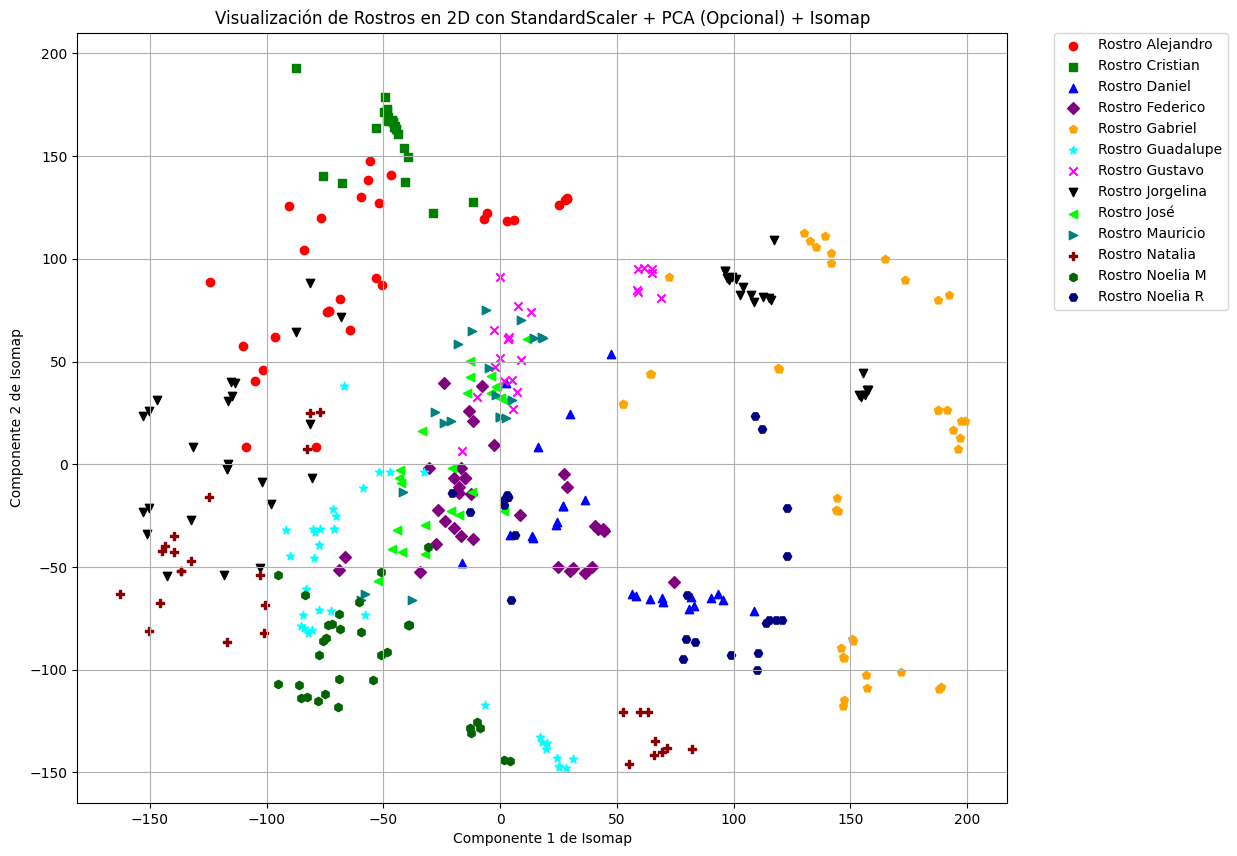

In [17]:
N_COMPONENTS_ISOMAP_VISUAL = 2 # Usamos 2 componentes para la visualización

# 1. Inicializar el StandardScaler
scaler = StandardScaler()

# 2. Escalar los datos
images_data_scaled = scaler.fit_transform(images_data)


# 3. Reducir la dimensionalidad con PCA (opcional)
if N_COMPONENTS_PCA != 0:
    pca = PCA(n_components=N_COMPONENTS_PCA, random_state=RANDOM_STATE)
    X_transformed_visual = pca.fit_transform(images_data_scaled)
    print(f"PCA aplicado antes de Isomap para visualización con {N_COMPONENTS_PCA} componentes.")
else:
    # Si PCA no se aplica, los datos transformados son los datos escalados
    X_transformed_visual = images_data_scaled
    print("PCA no se aplica antes de Isomap para visualización porque N_COMPONENTS_PCA es cero.")

# 4. Aplicar Isomap para visualización en los datos transformados
print(f"\nAplicando Isomap para visualizar con n_neighbors={N_NEIGHBORS} y n_components={N_COMPONENTS_ISOMAP_VISUAL}...")
isomap = Isomap(n_neighbors=N_NEIGHBORS, n_components=N_COMPONENTS_ISOMAP_VISUAL)

try:
    X_isomap_2d = isomap.fit_transform(X_transformed_visual)
    print("Isomap aplicado correctamente para visualización.")

    # 5. Crear el gráfico de dispersión
    plt.figure(figsize=(12, 10))

    # Define listas de colores y marcadores, asegurando que tengan al menos 13 elementos.
    colores = [
        'red', 'green', 'blue', 'purple', 'orange', 'cyan', 'magenta', 'black', 'lime', 'teal',
        'darkred', 'darkgreen', 'navy'
    ]
    marcadores = [
        'o', 's', '^', 'D', 'p', '*', 'x', 'v', '<', '>',
        'P', 'h', 'H'
    ]

    # Crea un scatter plot para cada etiqueta (persona)
    for i, color_actual, marcador_actual in zip(unique_labels, colores, marcadores):
        plt.scatter(
            X_isomap_2d[labels_data == i, 0],
            X_isomap_2d[labels_data == i, 1],
            label=f'Rostro {i}',
            c=color_actual,
            marker=marcador_actual
        )

    plt.title('Visualización de Rostros en 2D con StandardScaler + PCA (Opcional) + Isomap')
    plt.xlabel('Componente 1 de Isomap')
    plt.ylabel('Componente 2 de Isomap')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"ERROR: Fallo al aplicar Isomap para la visualización. Causa: {e}")